# 04 · Explainability: full-dataset SHAP, temporal variation, stability, categories

Everything is rebuilt from the recorded SHAP bundle (35,125 records by 20 features, with feature values, predictions, and split labels), so the explanation diagnostics cover the entire dataset rather than the test split only.  
The row identifiers follow chronological production order, although exact timestamps and elapsed intervals are unavailable.

### Setup

In [1]:
import matplotlib as mpl
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import shap as shap_lib
from xopa.explain import explanation_diagnostics

from _shared import (
    CATEGORY_COLORS,
    CHRONOLOGICAL_INTERVAL,
    DOUBLE_COL,
    N,
    ONE_HALF_COL,
    PROBE_COLOR,
    ROOT,
    SINGLE_COL,
    feature_category,
    init_notebook,
    run_dir,
)

FIG_DIR, savefig = init_notebook("04_explainability")

campaign: dce-full-rffs-4backbones-xgb-analyses-v2-2026-08-11
figures -> /Users/berthier/Development/PhD/xopa/results/notebook-figures/04_explainability


/Users/berthier/Development/PhD/xopa/.venv/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
exp_dir = run_dir("xgboost", "explain")
bundle = np.load(exp_dir / "shap_bundle.npz", allow_pickle=True)
feature_names = [str(f) for f in bundle["feature_names"]]
order = np.argsort(bundle["row_ids"])  # chronological production order
shap_values = pd.DataFrame(
    bundle["shap_values"][order], index=bundle["row_ids"][order], columns=feature_names
)
feature_values = pd.DataFrame(
    bundle["feature_values"][order], index=bundle["row_ids"][order], columns=feature_names
)
y_true = pd.Series(bundle["y_true"][order], index=bundle["row_ids"][order])
GROUP = 1500
importance = shap_values.abs().mean().sort_values(ascending=False)
# Additivity check on the recorded bundle: the base value plus the feature
# contributions must reproduce the stored prediction of every record.
phi0_offset = bundle["predictions"][order] - shap_values.sum(axis=1).to_numpy()
phi0 = float(phi0_offset.mean())
max_dev = float(np.abs(phi0_offset - phi0).max())
assert max_dev < 1e-5, f"additivity violated: max deviation {max_dev:.2e}"
print(f"records: {len(shap_values):,}; features: {len(feature_names)}")
print(f"additivity: phi_0 = {phi0:.6f}, max |deviation| = {max_dev:.2e} over all records")
importance.round(4).to_frame(f"mean |SHAP| ({N['I_j']})").head(10)

records: 35,125; features: 20
additivity: phi_0 = -0.000527, max |deviation| = 2.83e-06 over all records


,mean |SHAP| ($I_j$)
data_474,0.3041
data_118,0.1600
data_385,0.1258
data_108,0.0688
data_064,0.0633
data_475,0.0627
data_085,0.0528
data_054,0.0525
data_001,0.0516
data_002,0.0476


## Global importance beeswarm (all 35,125 records)

/var/folders/mv/1d09ddf12d58dknm06tlvydm0000gn/T/ipykernel_8162/3663033764.py:5: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  shap_lib.summary_plot(


saved: /Users/berthier/Development/PhD/xopa/results/notebook-figures/04_explainability/beeswarm_full_dataset.pdf/.png


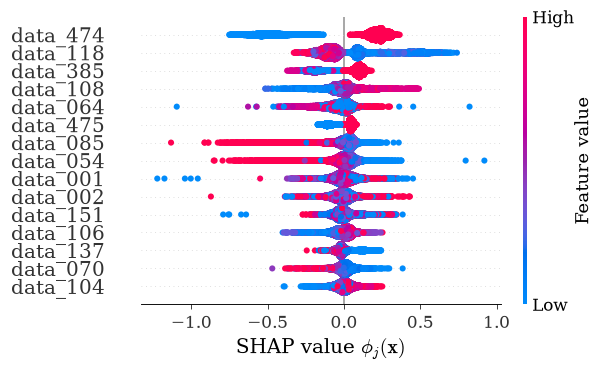

In [3]:
random_state = np.random.get_state()
np.random.seed(42)
try:
    with mpl.rc_context({"figure.constrained_layout.use": False}):
        shap_lib.summary_plot(
            shap_values.to_numpy(), feature_values, max_display=15, show=False,
            plot_size=(ONE_HALF_COL, 3.4),
        )
        fig = plt.gcf()
        fig.axes[0].set_xlabel(r"SHAP value $\phi_j(\mathbf{x})$")
        savefig(fig, "beeswarm_full_dataset")
        plt.show()
finally:
    np.random.set_state(random_state)

## SHAP dependence plots for the leading pairwise $k$-SII terms

The interaction pairs are read directly from the complete order-two ranking produced by [06_interactions.ipynb](06_interactions.ipynb), none is selected manually.  
Within each pair, the feature with the larger singleton $k$-SII value is placed on the horizontal axis and the companion feature supplies the colour scale. These are SHAP dependence plots, not classical partial-dependence curves.

,rank,primary,companion,mean_abs_ksii
0,1,data_108,data_151,0.092815
1,2,data_106,data_001,0.084956
2,3,data_118,data_108,0.078423


saved: /Users/berthier/Development/PhD/xopa/results/notebook-figures/04_explainability/shap_dependence_top_ksii_pairs.pdf/.png


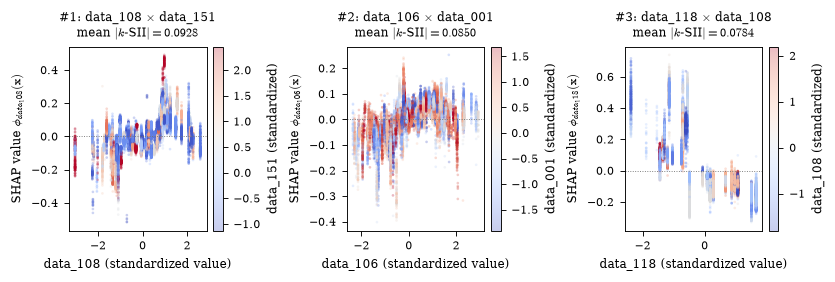

In [4]:
ksii_path = (
    ROOT
    / "results/notebook-figures/06_interactions"
    / "ksii_interaction_values.csv"
)
if not ksii_path.exists():
    raise FileNotFoundError(
        f"missing {ksii_path}; execute 06_interactions.ipynb before this cell"
    )
ksii = pd.read_csv(ksii_path)
required_columns = {"order", "label", "mean_abs_ksii"}
missing_columns = required_columns.difference(ksii.columns)
if missing_columns:
    raise ValueError(f"invalid k-SII table; missing columns: {sorted(missing_columns)}")

top_pairs = (
    ksii.query("order == 2")
    .sort_values("mean_abs_ksii", ascending=False, kind="mergesort")
    .head(3)
    .reset_index(drop=True)
)
singleton_ksii = ksii.query("order == 1").set_index("label")["mean_abs_ksii"]
if len(top_pairs) != 3:
    raise ValueError(f"expected at least three pairwise k-SII terms, found {len(top_pairs)}")

plot_rows = []
for rank, term in top_pairs.iterrows():
    members = term["label"].split(" x ")
    if len(members) != 2 or len(set(members)) != 2:
        raise ValueError(f"invalid pairwise k-SII label: {term['label']}")
    absent = [feature for feature in members if feature not in feature_names]
    if absent:
        raise ValueError(f"k-SII features absent from the SHAP bundle: {absent}")
    missing_singletons = [feature for feature in members if feature not in singleton_ksii]
    if missing_singletons:
        raise ValueError(f"missing singleton k-SII terms: {missing_singletons}")
    primary, companion = sorted(
        members, key=lambda feature: (-singleton_ksii.loc[feature], feature)
    )
    plot_rows.append(
        {
            "rank": rank + 1,
            "primary": primary,
            "companion": companion,
            "mean_abs_ksii": float(term["mean_abs_ksii"]),
        }
    )
plot_spec = pd.DataFrame(plot_rows)
display(plot_spec)

fig, axes = plt.subplots(1, len(plot_spec), figsize=(DOUBLE_COL, 2.45))
for ax, spec in zip(axes, plot_spec.itertuples(index=False), strict=True):
    colour = feature_values[spec.companion].to_numpy(dtype=float)
    lower, upper = np.nanpercentile(colour, [2.0, 98.0])
    if not np.isfinite(lower) or not np.isfinite(upper):
        raise ValueError(f"non-finite colour range for {spec.companion}")
    if lower == upper:
        lower, upper = lower - 0.5, upper + 0.5
    scatter = ax.scatter(
        feature_values[spec.primary],
        shap_values[spec.primary],
        c=colour,
        cmap="coolwarm",
        norm=mpl.colors.Normalize(vmin=lower, vmax=upper, clip=True),
        s=3,
        alpha=0.28,
        linewidths=0,
        rasterized=True,
    )
    ax.axhline(0, color="0.45", lw=0.6, ls=":")
    ax.set_xlabel(f"{spec.primary} (standardized value)")
    ax.set_ylabel(rf"SHAP value $\phi_{{{spec.primary}}}(\mathbf{{x}})$")
    ax.set_title(
        rf"#{spec.rank}: {spec.primary} $\times$ {spec.companion}"
        + "\n"
        + rf"mean $|k$-SII$|={spec.mean_abs_ksii:.4f}$"
    )
    fig.colorbar(scatter, ax=ax, label=f"{spec.companion} (standardized)")
savefig(fig, "shap_dependence_top_ksii_pairs")
plt.show()

## Reproducible fitted boundaries for the three leading variables

The three leading variables carry the clearest single-variable behaviour, so their dependence plots are shown alone with the model's highest-gain split location marked.  
The dashed line in each panel is that variable's highest-gain fitted split, which remains identical across the 20 bootstrap refits of the stability analysis, so each marked boundary is a reproducible property of the fitted model rather than a hand-drawn threshold.  
Points use the category colour of each variable.  
For `data_474` and `data_385` the fitted threshold coincides with a recorded level, which the split assigns to the upper side, so the dashed line overlaps that level's strip.

saved: /Users/berthier/Development/PhD/xopa/results/notebook-figures/04_explainability/shap_dependence_leading_variables.pdf/.png


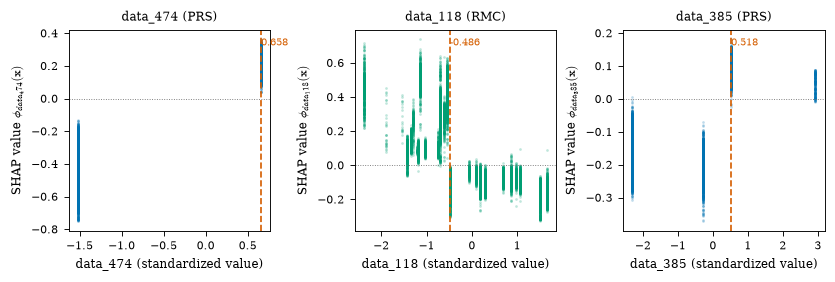

In [5]:
# Highest-gain split locations of the recorded stability analysis: identical
# across all 20 bootstrap refits (see 07_targeted_analyses.ipynb).
LEADING_SPLITS = {"data_474": 0.658, "data_118": -0.486, "data_385": 0.518}
leaders = list(importance.index[:3])
assert leaders == list(LEADING_SPLITS), f"leading variables changed: {leaders}"

fig, axes = plt.subplots(1, 3, figsize=(DOUBLE_COL, 2.45))
for ax, feature in zip(axes, leaders, strict=True):
    split = LEADING_SPLITS[feature]
    category = feature_category(feature)
    ax.scatter(
        feature_values[feature], shap_values[feature],
        color=CATEGORY_COLORS[category], s=3, alpha=0.25, linewidths=0,
        rasterized=True,
    )
    ax.axhline(0, color="0.45", lw=0.6, ls=":")
    ax.axvline(split, color=PROBE_COLOR, lw=1.1, ls="--")
    ax.annotate(
        f"{split:.3f}", xy=(split, 0.96), xycoords=("data", "axes fraction"),
        fontsize=6.5, ha="left", va="top", color=PROBE_COLOR,
    )
    ax.set_xlabel(f"{feature} (standardized value)")
    ax.set_ylabel(rf"SHAP value $\phi_{{{feature}}}(\mathbf{{x}})$")
    ax.set_title(f"{feature} ({category})")
savefig(fig, "shap_dependence_leading_variables")
plt.show()

## Temporal-variation heatmaps for the five most and five least important variables

The outlined interval is a broad post-hoc window spanning four complete groups (6,000 records) around the onset of the clearest signed change in `data_474`.  
It is retained unchanged in the later chronological-position and uncertainty analyses, but is not an estimated change point or a separately identified production regime.

diagnostics: 20 variables, 24 record groups


,record group,mean signed SHAP (data_474)
0,"22,500–23,999",0.157
1,"24,000–25,499",-0.408
2,"25,500–26,999",-0.507
3,"27,000–28,499",-0.499


saved: /Users/berthier/Development/PhD/xopa/results/notebook-figures/04_explainability/drift_heatmaps.pdf/.png


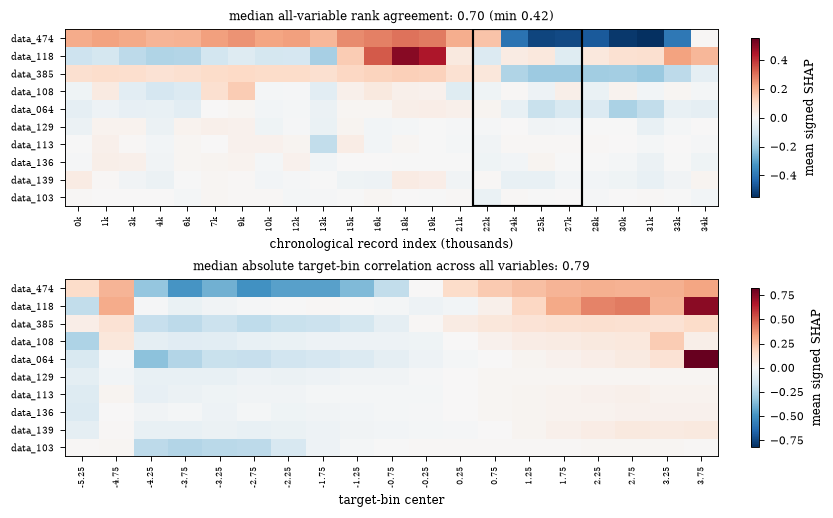

In [6]:
display_features = list(importance.index[:5]) + list(importance.index[-5:])
groups = np.arange(len(shap_values)) // GROUP
drift_idx = shap_values[display_features].groupby(groups).mean().T
drift_idx.columns = [f"{g * GROUP // 1000}k" for g in drift_idx.columns]
bins = pd.cut(y_true, np.arange(-5.5, 5.0, 0.5))
drift_out = shap_values[display_features].groupby(bins, observed=True).mean().T
drift_out.columns = [f"{iv.mid:.2f}" for iv in drift_out.columns]

stability, monotonic = explanation_diagnostics(
    shap_values, y_true, group_size=GROUP, bin_width=0.5
)
assert len(monotonic) == len(feature_names)
assert set(monotonic.index) == set(feature_names)
assert len(stability) == int(np.ceil(len(shap_values) / GROUP))
print(
    f"diagnostics: {len(monotonic)} variables, {len(stability)} record groups"
)

fig, axes = plt.subplots(2, 1, figsize=(DOUBLE_COL, 4.6))
for ax, drift, xlabel in (
    (axes[0], drift_idx, "chronological record index (thousands)"),
    (axes[1], drift_out, "target-bin center"),
):
    limit = float(np.nanmax(np.abs(drift.to_numpy())))
    im = ax.imshow(drift.to_numpy(), cmap="RdBu_r", vmin=-limit, vmax=limit, aspect="auto")
    ax.set_yticks(range(len(drift.index)), drift.index, fontsize=6)
    ax.set_xticks(range(len(drift.columns)), drift.columns, rotation=90, fontsize=5.5)
    ax.set_xlabel(xlabel)
    fig.colorbar(im, ax=ax, label="mean signed SHAP", shrink=0.9)
window_groups = [
    j for j in range(drift_idx.shape[1])
    if (j + 1) * GROUP > CHRONOLOGICAL_INTERVAL[0]
    and j * GROUP <= CHRONOLOGICAL_INTERVAL[1]
]
assert "data_474" in drift_idx.index
data_474_window = pd.DataFrame(
    {
        "record group": [
            f"{j * GROUP:,}–{min((j + 1) * GROUP - 1, len(shap_values) - 1):,}"
            for j in window_groups
        ],
        "mean signed SHAP (data_474)": (
            drift_idx.loc["data_474"].iloc[window_groups].to_numpy()
        ),
    }
)
display(data_474_window.round({"mean signed SHAP (data_474)": 3}))
axes[0].add_patch(
    plt.Rectangle((min(window_groups) - 0.5, -0.5), len(window_groups),
                  len(display_features), fill=False, edgecolor="black", lw=1.4)
)
axes[0].set_title(
    f"median all-variable rank agreement: {stability.median():.2f} "
    f"(min {stability.min():.2f})"
)
axes[1].set_title(
    f"median absolute target-bin correlation across all variables: "
    f"{monotonic.abs().median():.2f}"
)
savefig(fig, "drift_heatmaps")
plt.show()

## Stability statistics: all-variable rank agreement and top-5 persistence

,value
variables ranked,20.000000
record groups,24.000000
median rank agreement,0.696992
minimum rank agreement,0.422556
median top-5 persistence,0.800000
minimum top-5 persistence,0.600000


saved: /Users/berthier/Development/PhD/xopa/results/notebook-figures/04_explainability/stability_statistics.pdf/.png


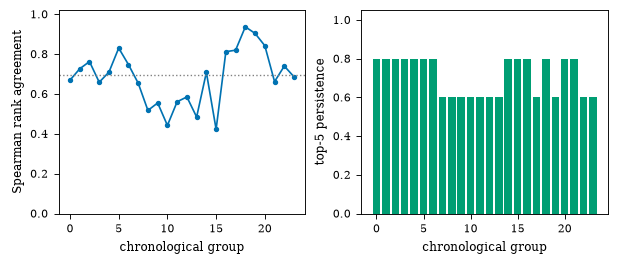

In [7]:
top5 = pd.read_csv(exp_dir / "top5_persistence.csv")
stability_summary = pd.Series(
    {
        "variables ranked": len(feature_names),
        "record groups": len(stability),
        "median rank agreement": stability.median(),
        "minimum rank agreement": stability.min(),
        "median top-5 persistence": top5["top_5_persistence"].median(),
        "minimum top-5 persistence": top5["top_5_persistence"].min(),
    },
    name="value",
)
display(stability_summary.to_frame())
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(ONE_HALF_COL, 2.3))
ax1.plot(stability.index, stability.to_numpy(), marker="o", ms=2.5, color="#0072B2")
ax1.axhline(stability.median(), color="gray", ls=":", lw=0.9)
ax1.set_xlabel("chronological group")
ax1.set_ylabel("Spearman rank agreement")
ax1.set_ylim(0, 1.02)
ax2.bar(top5["group"], top5["top_5_persistence"], color="#009E73", width=0.8)
ax2.set_xlabel("chronological group")
ax2.set_ylabel("top-5 persistence")
ax2.set_ylim(0, 1.05)
savefig(fig, "stability_statistics")
plt.show()

## Monotonicity of model contributions across target bins

,Spearman correlation
data_054,0.914286
data_002,0.890226
data_136,0.872180
data_064,0.866165
data_129,0.864662
data_139,0.861654
data_106,0.857143
data_085,0.818045
data_113,0.807519
data_104,0.790977


saved: /Users/berthier/Development/PhD/xopa/results/notebook-figures/04_explainability/monotonicity_lollipop.pdf/.png


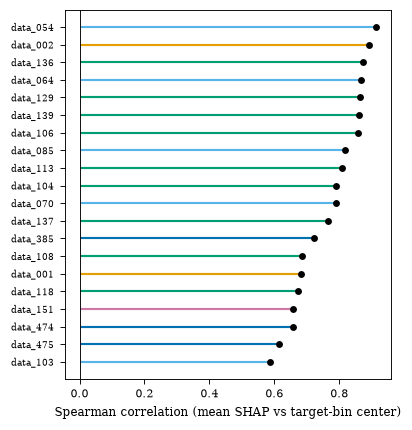

In [8]:
mono_sorted = monotonic.sort_values()
monotonic_by_strength = monotonic.reindex(
    monotonic.abs().sort_values(ascending=False).index
).rename("Spearman correlation")
display(monotonic_by_strength.to_frame())
fig, ax = plt.subplots(figsize=(SINGLE_COL, 3.8))
colors = [CATEGORY_COLORS.get(feature_category(f), "#999999") for f in mono_sorted.index]
ax.hlines(range(len(mono_sorted)), 0, mono_sorted.to_numpy(), colors=colors, lw=1.4)
ax.plot(mono_sorted.to_numpy(), range(len(mono_sorted)), "o", ms=3.5, color="black")
ax.set_yticks(range(len(mono_sorted)), mono_sorted.index, fontsize=6)
ax.axvline(0, color="black", lw=0.6)
ax.set_xlabel("Spearman correlation (mean SHAP vs target-bin center)")
savefig(fig, "monotonicity_lollipop")
plt.show()

## Category importance across the production sequence

For each production-order group, mean $|\phi_j(\mathbf{x})|$ is computed for every selected variable, summed within each process category, and normalized across the $20$ selected variables.

category source: /Users/berthier/Development/PhD/xopa/results/final-campaigns/dce-full-rffs-4backbones-xgb-analyses-v2-2026-08-11/xgboost/2026-08-11_18-29-34_explain_xgboost/shap_bundle.npz


,minimum group share (%),median group share (%),maximum group share (%)
CTX,4.14,6.95,11.10
PV,9.56,17.11,24.69
RMC,18.88,38.65,52.69
WC,1.79,3.04,6.72
PRS,22.97,32.49,50.88


,$\mathcal{D}^{\mathrm{ord}}$,remaining records,difference (percentage points)
CTX,6.12,7.52,-1.39
PV,19.52,16.43,3.10
RMC,27.22,38.32,-11.11
WC,2.89,3.61,-0.72
PRS,44.24,34.13,10.12


saved: /Users/berthier/Development/PhD/xopa/results/notebook-figures/04_explainability/category_share_by_group.pdf/.png


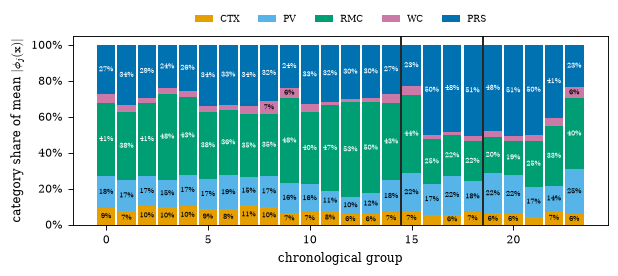

In [9]:
category_of = {f: feature_category(f) for f in feature_names}
abs_shap = shap_values.abs()
group_id = np.arange(len(abs_shap)) // GROUP
per_group_feature_importance = abs_shap.groupby(group_id).mean()
per_group_cat = (
    per_group_feature_importance
    .T.groupby(category_of)
    .sum()
    .reindex(CATEGORY_COLORS)
)
per_group_cat = per_group_cat / per_group_cat.sum(axis=0)
assert np.allclose(per_group_cat.sum(axis=0).to_numpy(), 1.0)

group_share_summary = (
    100 * per_group_cat.T.agg(["min", "median", "max"]).T
).rename(
    columns={
        "min": "minimum group share (%)",
        "median": "median group share (%)",
        "max": "maximum group share (%)",
    }
)
row_index = abs_shap.index.to_numpy()
in_window = (row_index >= CHRONOLOGICAL_INTERVAL[0]) & (
    row_index <= CHRONOLOGICAL_INTERVAL[1]
)
window_category_importance = (
    abs_shap.loc[in_window].mean().groupby(category_of).sum().reindex(CATEGORY_COLORS)
)
remaining_category_importance = (
    abs_shap.loc[~in_window].mean().groupby(category_of).sum().reindex(CATEGORY_COLORS)
)
window_comparison = 100 * pd.DataFrame(
    {
        r"$\mathcal{D}^{\mathrm{ord}}$": (
            window_category_importance / window_category_importance.sum()
        ),
        "remaining records": (
            remaining_category_importance / remaining_category_importance.sum()
        ),
    }
)
window_comparison["difference (percentage points)"] = (
    window_comparison.iloc[:, 0] - window_comparison.iloc[:, 1]
)
print(f"category source: {exp_dir / 'shap_bundle.npz'}")
display(group_share_summary.astype("float64").round(2))
display(window_comparison.astype("float64").round(2))

fig, ax = plt.subplots(figsize=(ONE_HALF_COL, 2.4))
bottom = np.zeros(per_group_cat.shape[1])
min_labeled_share = 0.055
for category in CATEGORY_COLORS:
    values = per_group_cat.loc[category].to_numpy()
    bars = ax.bar(range(per_group_cat.shape[1]), values, bottom=bottom,
                  color=CATEGORY_COLORS[category], width=0.9, label=category)
    label_color = "white" if category in {"RMC", "PRS"} else "black"
    ax.bar_label(
        bars,
        labels=[f"{value:.0%}" if value >= min_labeled_share else "" for value in values],
        label_type="center",
        color=label_color,
        fontsize=4.5,
        padding=0,
    )
    bottom += values
window_groups = [
    g for g in range(per_group_cat.shape[1])
    if (g + 1) * GROUP > CHRONOLOGICAL_INTERVAL[0]
    and g * GROUP <= CHRONOLOGICAL_INTERVAL[1]
]
ax.axvline(min(window_groups) - 0.5, color="black", lw=1.1)
ax.axvline(max(window_groups) + 0.5, color="black", lw=1.1)
ax.set_xlabel("chronological group")
ax.set_ylabel(r"category share of mean $|\phi_j(\mathbf{x})|$")
ax.yaxis.set_major_formatter(mpl.ticker.PercentFormatter(xmax=1.0))
ax.legend(ncol=5, fontsize=6, loc="upper center", bbox_to_anchor=(0.5, 1.16))
savefig(fig, "category_share_by_group")
plt.show()